# TP Bioinformatique COVID-19 - Partie 5
## Visualisation avec IGV et analyse de couverture
**Auteur : Marwa zidi**

**Durée estimée : 20 minutes**

### Objectifs
- Calculer la couverture et la profondeur
- Visualiser avec IGV Desktop via VNC 
- Analyser la qualité du séquençage
---

## 🎯 MÉTHODE DE VISUALISATION

Ce notebook propose une  visualisation avec IGV :
### Méthode : IGV Desktop via VNC 
- IGV complet dans le navigateur
- URL : http://localhost:6080/vnc.html
- Mot de passe : `NGS`
---

In [5]:
# Import des bibliothèques
import os
import subprocess
import pysam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO

print("✅ Bibliothèques standards chargées")



✅ Bibliothèques standards chargées


## 1. Préparation des fichiers

In [7]:
# Chemins des fichiers
sorted_bam = os.path.expanduser("~/notebooks-covid/alignment/alignment_sorted.bam")
sorted_bai = os.path.expanduser("~/notebooks-covid/alignment/alignment_sorted.bam.bai")
depth_file = os.path.expanduser("~/notebooks-covid/alignment/depth.txt")
reference_fasta = "/opt/covid_data/NC_045512.2.fasta"
reference_fai = "/opt/covid_data/NC_045512.2.fasta.fai"

# Vérification
print("📂 Vérification des fichiers...\n")
print(f"   BAM : {'✅' if os.path.exists(sorted_bam) else '❌'} {sorted_bam}")
print(f"   REF : {'✅' if os.path.exists(reference_fasta) else '❌'} {reference_fasta}")

# Création de l'index BAM si nécessaire
if not os.path.exists(sorted_bai):
    print("\n🔧 Création de l'index BAM...")
    subprocess.run(f"samtools index {sorted_bam}", shell=True)
    print("✅ Index BAM créé")
else:
    print(f"   BAI : ✅ {sorted_bai}")

# Création de l'index FASTA si nécessaire
if not os.path.exists(reference_fai):
    print("\n🔧 Création de l'index FASTA...")
    subprocess.run(f"samtools faidx {reference_fasta}", shell=True)
    print("✅ Index FASTA créé")
else:
    print(f"   FAI : ✅ {reference_fai}")

📂 Vérification des fichiers...

   BAM : ✅ /root/notebooks-covid/alignment/alignment_sorted.bam
   REF : ✅ /opt/covid_data/NC_045512.2.fasta
   BAI : ✅ /root/notebooks-covid/alignment/alignment_sorted.bam.bai
   FAI : ✅ /opt/covid_data/NC_045512.2.fasta.fai


## 2. Calcul de la profondeur

In [8]:
# Calcul de profondeur
if os.path.exists(sorted_bam):
    print("📊 Calcul de la profondeur...")
    subprocess.run(f"samtools depth -a {sorted_bam} > {depth_file}", shell=True)
    
    depth_data = pd.read_csv(depth_file, sep='\t', names=['chromosome', 'position', 'depth'])
    
    print(f"\n✅ Statistiques :")
    print(f"   Profondeur moyenne : {depth_data['depth'].mean():.2f}X")
    print(f"   Médiane : {depth_data['depth'].median():.0f}X")
    print(f"   Couverture : {(depth_data['depth'] > 0).sum()/len(depth_data)*100:.2f}%")
    print(f"   ≥ 30X : {(depth_data['depth'] >= 30).sum()/len(depth_data)*100:.1f}%")

📊 Calcul de la profondeur...

✅ Statistiques :
   Profondeur moyenne : 382.29X
   Médiane : 1X
   Couverture : 57.35%
   ≥ 30X : 7.0%


## 3. Graphiques de profondeur

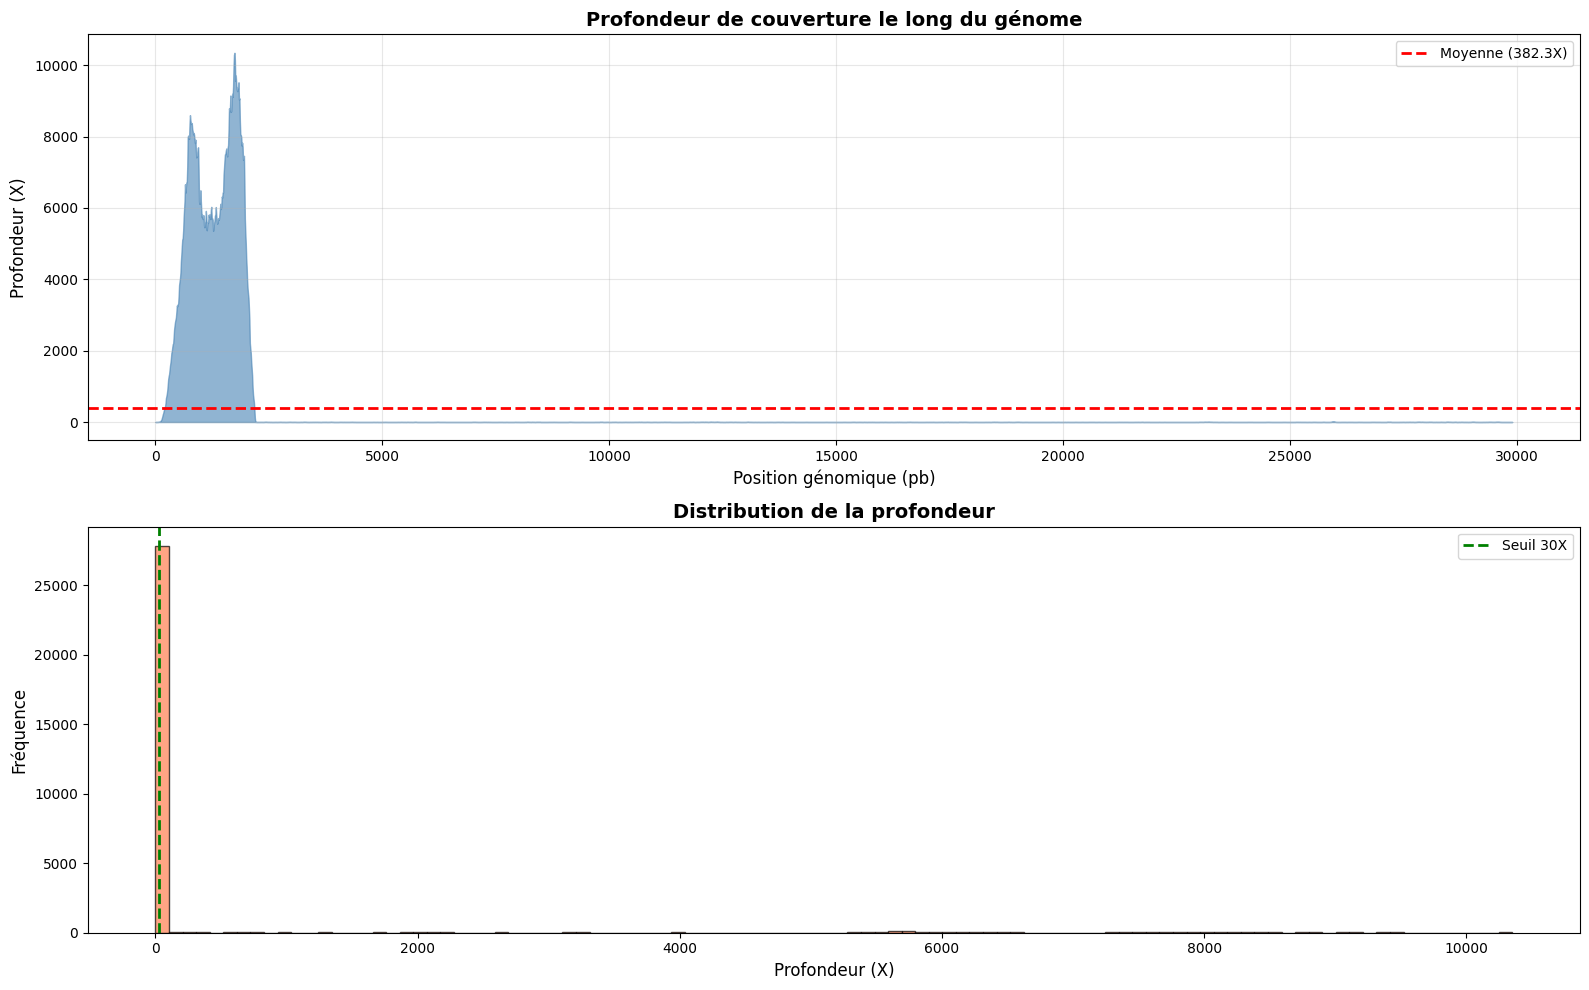

In [9]:
# Graphiques
if os.path.exists(depth_file):
    depth_data = pd.read_csv(depth_file, sep='\t', names=['chromosome', 'position', 'depth'])
    sampled = depth_data[::10]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    
    ax1.fill_between(sampled['position'], sampled['depth'], alpha=0.6, color='steelblue')
    ax1.axhline(y=depth_data['depth'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f"Moyenne ({depth_data['depth'].mean():.1f}X)")
    ax1.set_xlabel('Position génomique (pb)', fontsize=12)
    ax1.set_ylabel('Profondeur (X)', fontsize=12)
    ax1.set_title('Profondeur de couverture le long du génome', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(depth_data['depth'], bins=100, edgecolor='black', alpha=0.7, color='coral')
    ax2.axvline(x=30, color='green', linestyle='--', linewidth=2, label='Seuil 30X')
    ax2.set_xlabel('Profondeur (X)', fontsize=12)
    ax2.set_ylabel('Fréquence', fontsize=12)
    ax2.set_title('Distribution de la profondeur', fontsize=14, fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

## 4. Visualisation: IGV Desktop via VNC 

### 🖥️ Accès à IGV Desktop dans le navigateur

  
    1️⃣ Ouvrez un nouvel onglet dans votre navigateur")
    2️⃣ Allez à : http://localhost:6080/vnc.html")
    3️⃣ Cliquez sur 'Connect'")
    4️⃣ Mot de passe : NGS")
    5️⃣ Dans le bureau Linux :")
      - Clic droit → Menu → IGV")
       - Ou : Terminal → tapez 'igv.sh'")
    6️⃣ Chargez les fichiers :")
       - Genomes → Load from File → {reference_fasta}")
       - File → Load from File → {sorted_bam}")
    7️⃣ Naviguez vers les régions d'intérêt :")


## 5. Analyse par gène

In [10]:
# Analyse par gène
genbank_file = "/opt/covid_data/NC_045512.2.gb"

if os.path.exists(genbank_file) and os.path.exists(depth_file):
    genome = SeqIO.read(genbank_file, "genbank")
    depth_data = pd.read_csv(depth_file, sep='\t', names=['chromosome', 'position', 'depth'])
    
    gene_coverage = []
    for feature in genome.features:
        if feature.type == "gene":
            gene_name = feature.qualifiers.get('gene', ['Unknown'])[0]
            start = int(feature.location.start) + 1
            end = int(feature.location.end)
            
            gene_depth = depth_data[(depth_data['position'] >= start) & 
                                   (depth_data['position'] <= end)]
            
            if len(gene_depth) > 0:
                avg_depth = gene_depth['depth'].mean()
                coverage_pct = (gene_depth['depth'] > 0).sum() / len(gene_depth) * 100
                
                gene_coverage.append({
                    'Gene': gene_name,
                    'Start': start,
                    'End': end,
                    'Avg_Depth': f"{avg_depth:.1f}X",
                    'Coverage': f"{coverage_pct:.1f}%"
                })
    
    df_coverage = pd.DataFrame(gene_coverage)
    print("📊 COUVERTURE PAR GÈNE :\n")
    print(df_coverage.to_string(index=False))

📊 COUVERTURE PAR GÈNE :

  Gene  Start   End Avg_Depth Coverage
ORF1ab    266 21555    533.6X    58.4%
     S  21563 25384      0.8X    39.7%
 ORF3a  25393 26220      2.1X    53.5%
     E  26245 26472      0.5X    51.3%
     M  26523 27191      0.9X    50.4%
  ORF6  27202 27387      0.8X    20.4%
 ORF7a  27394 27759      1.3X    80.1%
 ORF7b  27756 27887      4.0X    89.4%
  ORF8  27894 28259      2.3X    94.5%
     N  28274 29533      2.1X    84.2%
 ORF10  29558 29674      3.2X    81.2%


## 6. Rapport final

In [12]:
# Rapport final
if os.path.exists(depth_file):
    depth_data = pd.read_csv(depth_file, sep='\t', names=['chromosome', 'position', 'depth'])
    
    print("\n" + "="*70)
    print(" "*20 + "📋 RAPPORT FINAL")
    print("="*70)
    
    covered = (depth_data['depth'] > 0).sum()
    total = len(depth_data)
    
    print("\n📊 COUVERTURE :")
    print(f"   Couverture : {covered/total*100:.2f}%")
    print(f"\n📈 PROFONDEUR :")
    print(f"   Moyenne : {depth_data['depth'].mean():.2f}X")
    print(f"   Médiane : {depth_data['depth'].median():.0f}X")
    print(f"   ≥ 30X : {(depth_data['depth'] >= 30).sum()/total*100:.1f}%")
    
  
    print("\n" + "="*70)


                    📋 RAPPORT FINAL

📊 COUVERTURE :
   Couverture : 57.35%

📈 PROFONDEUR :
   Moyenne : 382.29X
   Médiane : 1X
   ≥ 30X : 7.0%



## 🎯 Résumé 

### Méthode 1 : IGV Desktop via VNC

**Avantages :**
- ✅ IGV complet (toutes les fonctionnalités)
- ✅ Fonctionne à 100%
- ✅ Interface native

**Inconvénients :**
- ⚠️ Nécessite un 2ème onglet
- ⚠️ Légèrement plus lent (via VNC)
---

## 🎉 FIN DU TP !

### Workflow NGS complet
```
FASTQ → FastQC → BWA → SAM/BAM → IGV → Variants
```

### Ce que vous avez appris
- ✅ Formats de fichiers bioinformatiques
- ✅ Contrôle qualité des séquences
- ✅ Alignement de reads
- ✅ Manipulation de fichiers BAM
- ✅ Analyse de couverture
- ✅ Visualisation avec IGV (ipyigv OU Desktop)

**🔬 Pipeline bioinformatique complet maîtrisé !**